In [1]:
#%pip install scipy
#%pip install tensorflow
#%pip install pandas
#%pip install seaborn
#%pip install numpy
#%pip install scikit-learn
#%pip install matplotlib
#%pip install python-chess

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import chess
import random
import re

#imports for transformed model
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, cross_val_score, GroupKFold
from sklearn.utils.class_weight import compute_class_weight


#tensorflow imports for transformer model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import TextVectorization, Embedding, Dense, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dropout, Concatenate

In [2]:
random.seed(42)
np.random.seed(42)


# -------------------------------
# 1. Load Dataset
# -------------------------------

DATASET_PATH = "dataset_"

with open(DATASET_PATH, "r") as f:
    lines = f.readlines()

data_start = next(i for i, line in enumerate(lines) if "@DATA" in line)

dataset = pd.read_csv(DATASET_PATH, skiprows=data_start + 1, header=None)

dataset.columns = [
    "id", "rated", "created_at", "last_move_at", "turns",
    "victory_status", "winner", "increment_code",
    "white_id", "white_rating", "black_id", "black_rating",
    "moves", "opening_eco", "opening_name", "opening_ply"
]


# -------------------------------
# 2. Basic Feature Engineering BEFORE Split
# -------------------------------

dataset["moves_clean"] = dataset["moves"].astype(str).str.strip().str.strip("'")

# Rating features
dataset["rating_diff"] = dataset["white_rating"] - dataset["black_rating"]
dataset["rating_abs_diff"] = dataset["rating_diff"].abs()
dataset["white_higher_rated"] = (dataset["white_rating"] > dataset["black_rating"]).astype(int)

# Time control features
dataset[["base_time", "time_increment"]] = dataset["increment_code"].astype(str).str.split("+", expand=True)
dataset["base_time"] = dataset["base_time"].astype(int)
dataset["time_increment"] = dataset["time_increment"].astype(int)

# Opening features
dataset["opening_letter"] = dataset["opening_eco"].astype(str).str[0]
dataset["opening_number"] = dataset["opening_eco"].astype(str).str.extract(r"([0-9]{2})")[0].astype(int)
dataset["opening_number_bucket"] = (dataset["opening_number"] // 10).astype(int)
dataset["opening_tens_digit"] = (dataset["opening_number"] // 10).astype(int)
dataset["opening_ones_digit"] = (dataset["opening_number"] % 10).astype(int)
dataset["opening_ply"] = dataset["opening_ply"].astype(int)

# Rated feature
dataset["rated"] = dataset["rated"].astype(str).str.lower().map({"true": 1, "false": 0}).astype(int)


# -------------------------------
# 3. Player Features BEFORE Split
# -------------------------------

def extract_name_features(name):
    name = str(name)

    length = len(name)
    has_number = int(any(c.isdigit() for c in name))

    numbers = re.findall(r"\d+", name)
    numbers = [int(n) for n in numbers]

    age_like = int(any(10 <= n <= 2000 for n in numbers))

    return length, has_number, age_like


def add_player_features(df):
    df = df.copy()

    white_features = pd.DataFrame(
        df["white_id"].apply(extract_name_features).tolist(),
        columns=["white_name_length", "white_has_number", "white_age_like"],
        index=df.index
    )

    black_features = pd.DataFrame(
        df["black_id"].apply(extract_name_features).tolist(),
        columns=["black_name_length", "black_has_number", "black_age_like"],
        index=df.index
    )

    return pd.concat([df, white_features, black_features], axis=1)


def is_daytime(timestamp):
    hour = pd.to_datetime(timestamp, unit="s").hour
    return int(8 <= hour < 20)


dataset = add_player_features(dataset)

dataset["is_daytime"] = dataset["created_at"].apply(is_daytime)
dataset["is_night"] = 1 - dataset["is_daytime"]


# -------------------------------
# 4. Encode Targets BEFORE Split
# -------------------------------

winner_encoder = LabelEncoder()
status_encoder = LabelEncoder()

dataset["y_winner"] = winner_encoder.fit_transform(dataset["winner"])
dataset["y_status"] = status_encoder.fit_transform(dataset["victory_status"])

print("Winner classes:", list(winner_encoder.classes_))
print("Status classes:", list(status_encoder.classes_))


# -------------------------------
# 5. Train/Test Split BEFORE Snapshot Expansion
# -------------------------------

train_df, test_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=dataset["y_winner"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# -------------------------------
# 6. Create Game Snapshots
# -------------------------------

def make_snapshot(move_string, progress):
    moves = str(move_string).split()

    if len(moves) == 0:
        board = chess.Board()
        return "", board.fen(), progress, 0

    cutoff = max(1, int(progress * len(moves)))
    cutoff = min(cutoff, len(moves))

    partial_moves = moves[:cutoff]
    board = chess.Board()

    try:
        for move in partial_moves:
            board.push_san(move)

        # Prevent terminal-position leakage
        if board.is_game_over() and len(partial_moves) > 1:
            partial_moves = partial_moves[:-1]
            board = chess.Board()

            for move in partial_moves:
                board.push_san(move)

        truncated_moves = " ".join(partial_moves)
        fen = board.fen()

    except Exception:
        board = chess.Board()
        truncated_moves = ""
        fen = board.fen()
        partial_moves = []

    return truncated_moves, fen, progress, len(partial_moves)


def expand_games(df, progress_points):
    expanded_rows = []

    for _, row in df.iterrows():
        row_dict = row.to_dict()

        for progress in progress_points:
            truncated_moves, fen, actual_progress, num_moves_used = make_snapshot(
                row_dict["moves_clean"],
                progress
            )

            new_row = row_dict.copy()
            new_row["moves_truncated"] = truncated_moves
            new_row["fen"] = fen
            new_row["progress"] = actual_progress
            new_row["num_moves_used"] = num_moves_used

            expanded_rows.append(new_row)

    return pd.DataFrame(expanded_rows).reset_index(drop=True)


train_progress_points = [0.2, 0.4, 0.6, 0.8, 0.95]
test_progress_points = [0.2, 0.4, 0.6, 0.8, 0.95]

train_expanded = expand_games(train_df, train_progress_points)
test_expanded = expand_games(test_df, test_progress_points)


# -------------------------------
# 7. FEN / Board Feature Extraction
# -------------------------------

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0
}

CENTER_SQUARES = [chess.D4, chess.E4, chess.D5, chess.E5]


def same_file(sq1, sq2):
    return chess.square_file(sq1) == chess.square_file(sq2)


def same_rank(sq1, sq2):
    return chess.square_rank(sq1) == chess.square_rank(sq2)


def same_diagonal(sq1, sq2):
    return abs(chess.square_file(sq1) - chess.square_file(sq2)) == \
           abs(chess.square_rank(sq1) - chess.square_rank(sq2))


def count_rook_batteries(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    count = 0

    for i in range(len(rooks)):
        for j in range(i + 1, len(rooks)):
            if same_file(rooks[i], rooks[j]) or same_rank(rooks[i], rooks[j]):
                count += 1

    return count


def count_queen_rook_batteries(board, color):
    queens = list(board.pieces(chess.QUEEN, color))
    rooks = list(board.pieces(chess.ROOK, color))
    count = 0

    for q in queens:
        for r in rooks:
            if same_file(q, r) or same_rank(q, r):
                count += 1

    return count


def count_bishop_queen_batteries(board, color):
    queens = list(board.pieces(chess.QUEEN, color))
    bishops = list(board.pieces(chess.BISHOP, color))
    count = 0

    for q in queens:
        for b in bishops:
            if same_diagonal(q, b):
                count += 1

    return count


def has_alekhines_gun(board, color):
    rooks = list(board.pieces(chess.ROOK, color))
    queens = list(board.pieces(chess.QUEEN, color))

    if len(rooks) < 2 or len(queens) < 1:
        return 0

    for q in queens:
        aligned_rooks = 0

        for r in rooks:
            if same_file(q, r) or same_rank(q, r):
                aligned_rooks += 1

        if aligned_rooks >= 2:
            return 1

    return 0


def count_central_knights(board, color):
    central_squares = {
        chess.C3, chess.D3, chess.E3, chess.F3,
        chess.C4, chess.D4, chess.E4, chess.F4,
        chess.C5, chess.D5, chess.E5, chess.F5,
        chess.C6, chess.D6, chess.E6, chess.F6,
    }

    return sum(1 for k in board.pieces(chess.KNIGHT, color) if k in central_squares)


def count_doubled_pawns(board, color):
    files = []

    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type == chess.PAWN:
            files.append(chess.square_file(square))

    return sum(files.count(f) > 1 for f in set(files))


def count_isolated_pawns(board, color):
    pawn_files = set()

    for square, piece in board.piece_map().items():
        if piece.color == color and piece.piece_type == chess.PAWN:
            pawn_files.add(chess.square_file(square))

    isolated = 0

    for f in pawn_files:
        if (f - 1 not in pawn_files) and (f + 1 not in pawn_files):
            isolated += 1

    return isolated


def fen_to_features(fen):
    board = chess.Board(fen)
    piece_map = board.piece_map()
    features = {}

    # Side to move
    features["white_to_move"] = int(board.turn == chess.WHITE)
    features["black_to_move"] = int(board.turn == chess.BLACK)

    # Castling rights
    features["white_can_castle_kingside"] = int(board.has_kingside_castling_rights(chess.WHITE))
    features["white_can_castle_queenside"] = int(board.has_queenside_castling_rights(chess.WHITE))
    features["black_can_castle_kingside"] = int(board.has_kingside_castling_rights(chess.BLACK))
    features["black_can_castle_queenside"] = int(board.has_queenside_castling_rights(chess.BLACK))

    # En passant / move counters
    features["has_en_passant"] = int(board.ep_square is not None)
    features["halfmove_clock"] = board.halfmove_clock
    features["fullmove_number"] = board.fullmove_number

    # Tactical / positional formations
    features["white_rook_batteries"] = count_rook_batteries(board, chess.WHITE)
    features["black_rook_batteries"] = count_rook_batteries(board, chess.BLACK)
    features["rook_battery_diff"] = features["white_rook_batteries"] - features["black_rook_batteries"]

    features["white_qr_batteries"] = count_queen_rook_batteries(board, chess.WHITE)
    features["black_qr_batteries"] = count_queen_rook_batteries(board, chess.BLACK)
    features["qr_battery_diff"] = features["white_qr_batteries"] - features["black_qr_batteries"]

    features["white_bq_batteries"] = count_bishop_queen_batteries(board, chess.WHITE)
    features["black_bq_batteries"] = count_bishop_queen_batteries(board, chess.BLACK)
    features["bq_battery_diff"] = features["white_bq_batteries"] - features["black_bq_batteries"]

    features["white_alekhines_gun"] = has_alekhines_gun(board, chess.WHITE)
    features["black_alekhines_gun"] = has_alekhines_gun(board, chess.BLACK)
    features["alekhines_gun_diff"] = features["white_alekhines_gun"] - features["black_alekhines_gun"]

    features["white_central_knights"] = count_central_knights(board, chess.WHITE)
    features["black_central_knights"] = count_central_knights(board, chess.BLACK)
    features["central_knight_diff"] = features["white_central_knights"] - features["black_central_knights"]

    # Check state and mobility
    features["side_to_move_in_check"] = int(board.is_check())
    features["num_legal_moves"] = len(list(board.legal_moves))

    # Material and piece counts
    white_material = 0
    black_material = 0

    for piece_type in PIECE_VALUES:
        white_count = len(board.pieces(piece_type, chess.WHITE))
        black_count = len(board.pieces(piece_type, chess.BLACK))
        piece_name = chess.piece_name(piece_type)

        features[f"white_{piece_name}s"] = white_count
        features[f"black_{piece_name}s"] = black_count
        features[f"{piece_name}_diff"] = white_count - black_count

        white_material += white_count * PIECE_VALUES[piece_type]
        black_material += black_count * PIECE_VALUES[piece_type]

    features["white_material"] = white_material
    features["black_material"] = black_material
    features["material_diff"] = white_material - black_material
    features["material_abs_diff"] = abs(white_material - black_material)

    features["white_total_pieces"] = sum(1 for p in piece_map.values() if p.color == chess.WHITE)
    features["black_total_pieces"] = sum(1 for p in piece_map.values() if p.color == chess.BLACK)
    features["piece_count_diff"] = features["white_total_pieces"] - features["black_total_pieces"]

    # Center control
    white_center_control = 0
    black_center_control = 0

    for sq in CENTER_SQUARES:
        white_center_control += len(board.attackers(chess.WHITE, sq))
        black_center_control += len(board.attackers(chess.BLACK, sq))

    features["white_center_control"] = white_center_control
    features["black_center_control"] = black_center_control
    features["center_control_diff"] = white_center_control - black_center_control

    # King safety proxy
    white_king_sq = board.king(chess.WHITE)
    black_king_sq = board.king(chess.BLACK)

    features["white_king_attackers"] = (
        len(board.attackers(chess.BLACK, white_king_sq))
        if white_king_sq is not None else 0
    )

    features["black_king_attackers"] = (
        len(board.attackers(chess.WHITE, black_king_sq))
        if black_king_sq is not None else 0
    )

    features["king_attackers_diff"] = (
        features["black_king_attackers"] - features["white_king_attackers"]
    )

    # Pawn structure
    features["white_doubled_pawns"] = count_doubled_pawns(board, chess.WHITE)
    features["black_doubled_pawns"] = count_doubled_pawns(board, chess.BLACK)
    features["doubled_pawn_diff"] = features["white_doubled_pawns"] - features["black_doubled_pawns"]

    features["white_isolated_pawns"] = count_isolated_pawns(board, chess.WHITE)
    features["black_isolated_pawns"] = count_isolated_pawns(board, chess.BLACK)
    features["isolated_pawn_diff"] = features["white_isolated_pawns"] - features["black_isolated_pawns"]

    return features


def add_fen_features(df):
    fen_feature_df = pd.DataFrame([fen_to_features(fen) for fen in df["fen"]])
    return pd.concat([df.reset_index(drop=True), fen_feature_df.reset_index(drop=True)], axis=1)


train_expanded = add_fen_features(train_expanded)
test_expanded = add_fen_features(test_expanded)


# -------------------------------
# 8. One-Hot ECO Features AFTER Expansion
# -------------------------------

eco_letter_categories = ["A", "B", "C", "D", "E"]
eco_bucket_categories = list(range(10))

train_expanded["opening_letter"] = pd.Categorical(
    train_expanded["opening_letter"],
    categories=eco_letter_categories
)

test_expanded["opening_letter"] = pd.Categorical(
    test_expanded["opening_letter"],
    categories=eco_letter_categories
)

train_expanded["opening_number_bucket"] = pd.Categorical(
    train_expanded["opening_number_bucket"],
    categories=eco_bucket_categories
)

test_expanded["opening_number_bucket"] = pd.Categorical(
    test_expanded["opening_number_bucket"],
    categories=eco_bucket_categories
)

train_eco_letter = pd.get_dummies(train_expanded["opening_letter"], prefix="eco_letter")
test_eco_letter = pd.get_dummies(test_expanded["opening_letter"], prefix="eco_letter")

train_eco_bucket = pd.get_dummies(train_expanded["opening_number_bucket"], prefix="eco_bucket")
test_eco_bucket = pd.get_dummies(test_expanded["opening_number_bucket"], prefix="eco_bucket")

train_expanded = pd.concat([train_expanded, train_eco_letter, train_eco_bucket], axis=1)
test_expanded = pd.concat([test_expanded, test_eco_letter, test_eco_bucket], axis=1)


# -------------------------------
# 9. Final Feature Columns
# -------------------------------

base_feature_cols = [
    "rated",
    "white_rating",
    "black_rating",
    "rating_diff",
    "rating_abs_diff",
    "white_higher_rated",
    "base_time",
    "time_increment",
    "opening_ply",
    "opening_number",
    "opening_tens_digit",
    "opening_ones_digit",
    "num_moves_used"
]

player_feature_cols = [
    "white_name_length",
    "white_has_number",
    "white_age_like",
    "black_name_length",
    "black_has_number",
    "black_age_like",
    "is_daytime",
    "is_night"
]

excluded_cols = set(dataset.columns).union({
    "moves_truncated",
    "fen",
    "progress",
    "num_moves_used"
})

fen_feature_cols = [
    col for col in train_expanded.columns
    if col not in excluded_cols
    and not col.startswith("eco_letter_")
    and not col.startswith("eco_bucket_")
]

eco_cols = [
    col for col in train_expanded.columns
    if col.startswith("eco_letter_") or col.startswith("eco_bucket_")
]

feature_cols = list(dict.fromkeys(
    base_feature_cols +
    player_feature_cols +
    fen_feature_cols +
    eco_cols
))


# -------------------------------
# 10. Final Model Inputs / Outputs
# -------------------------------

X_train_global = train_expanded[feature_cols].astype(float)
X_test_global = test_expanded[feature_cols].astype(float)

y_winner_train = train_expanded["winner"]
y_winner_test = test_expanded["winner"]

y_status_train = train_expanded["victory_status"]
y_status_test = test_expanded["victory_status"]

y_winner_train_encoded = train_expanded["y_winner"].values
y_winner_test_encoded = test_expanded["y_winner"].values

y_status_train_encoded = train_expanded["y_status"].values
y_status_test_encoded = test_expanded["y_status"].values


# -------------------------------
# 11. Sanity Checks
# -------------------------------

print("\nOriginal training games:", len(train_df))
print("Expanded training snapshots:", len(train_expanded))
print("Original testing games:", len(test_df))
print("Expanded testing snapshots:", len(test_expanded))

print("\nNumber of global features:", len(feature_cols))
print("X_train_global shape:", X_train_global.shape)
print("X_test_global shape:", X_test_global.shape)

print("\nExample truncated moves:")
print(train_expanded.loc[0, "moves_truncated"])

print("\nExample FEN:")
print(train_expanded.loc[0, "fen"])

print("\nFirst 30 feature columns:")
print(feature_cols[:30])

print("\nNew feature checks:")
print([
    col for col in feature_cols
    if "battery" in col
    or "alek" in col
    or "central_knight" in col
    or "name" in col
    or "age_like" in col
    or "day" in col
    or "night" in col
    or "opening_number" in col
])

Winner classes: ['black', 'draw', 'white']
Status classes: ['draw', 'mate', 'outoftime', 'resign']

Original training games: 16046
Expanded training snapshots: 80230
Original testing games: 4012
Expanded testing snapshots: 20060

Number of global features: 99
X_train_global shape: (80230, 99)
X_test_global shape: (20060, 99)

Example truncated moves:
e4 e6 b3 d5 f3 Nc6 Bb2 dxe4 fxe4 Qh4+ Ke2 Qxe4+ Kf2 Bc5+

Example FEN:
r1b1k1nr/ppp2ppp/2n1p3/2b5/4q3/1P6/PBPP1KPP/RN1Q1BNR w kq - 2 8

First 30 feature columns:
['rated', 'white_rating', 'black_rating', 'rating_diff', 'rating_abs_diff', 'white_higher_rated', 'base_time', 'time_increment', 'opening_ply', 'opening_number', 'opening_tens_digit', 'opening_ones_digit', 'num_moves_used', 'white_name_length', 'white_has_number', 'white_age_like', 'black_name_length', 'black_has_number', 'black_age_like', 'is_daytime', 'is_night', 'white_to_move', 'black_to_move', 'white_can_castle_kingside', 'white_can_castle_queenside', 'black_can_castle_kingsi

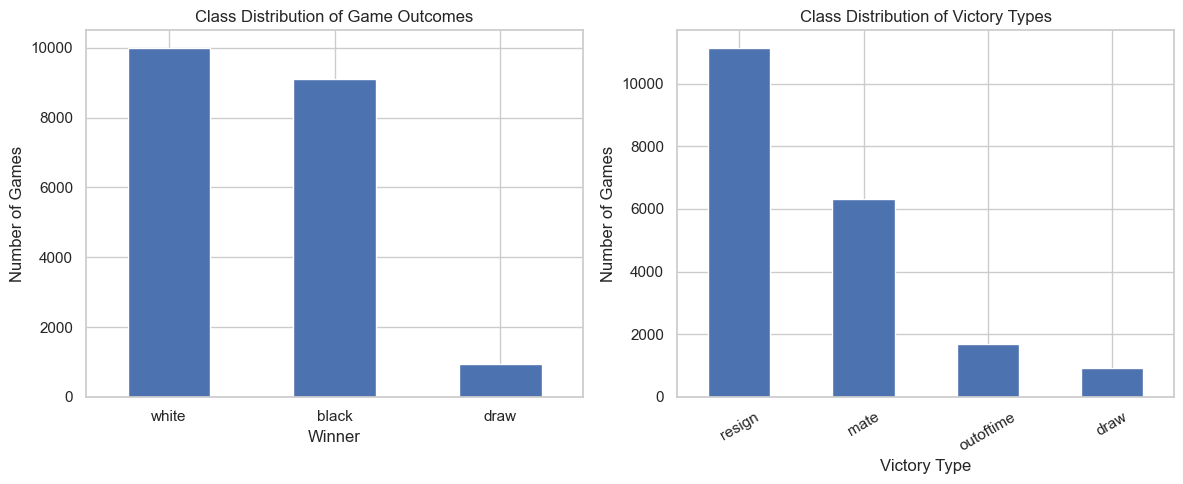

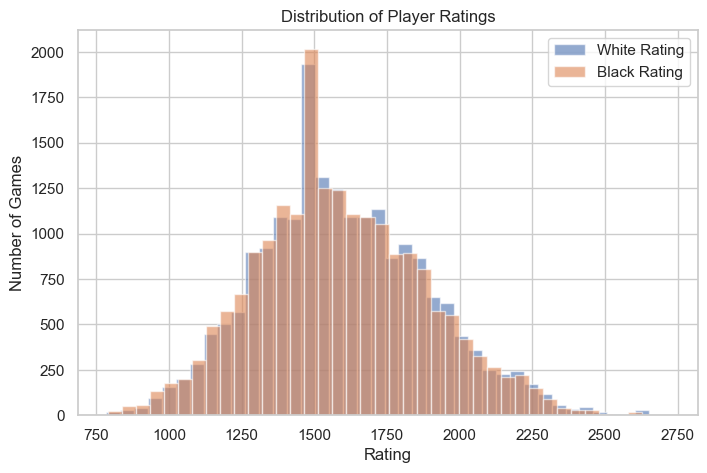

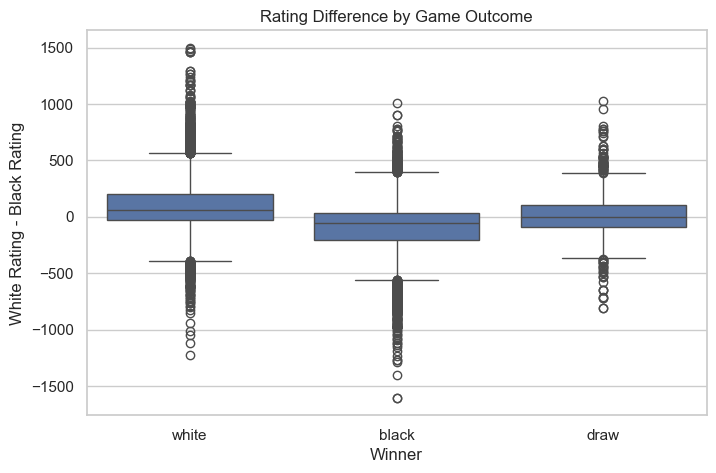

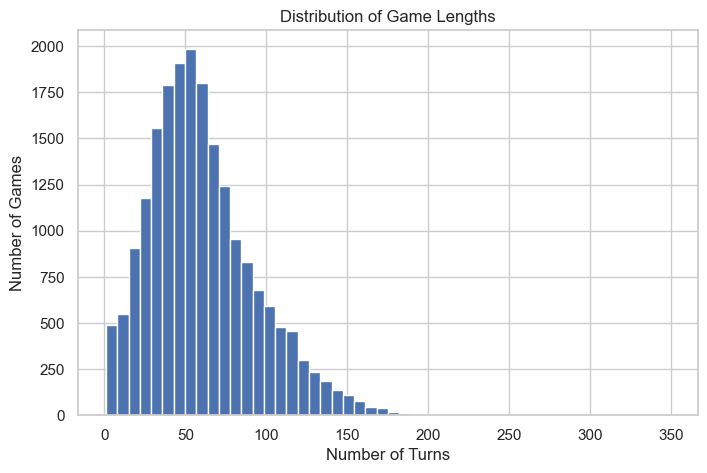

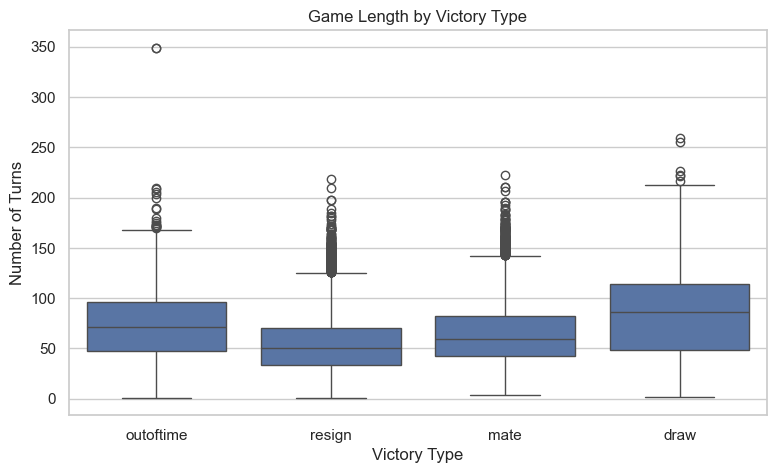

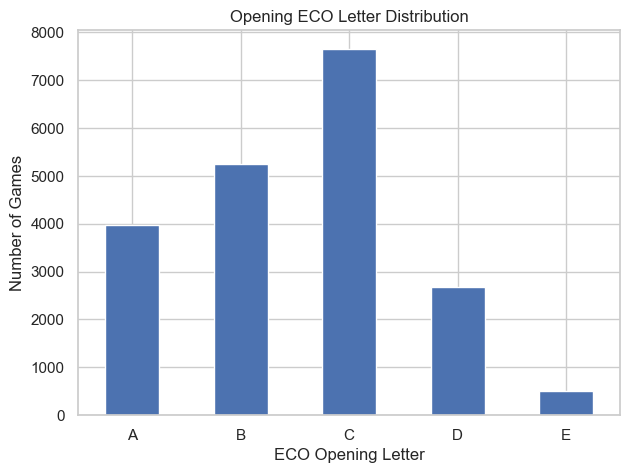

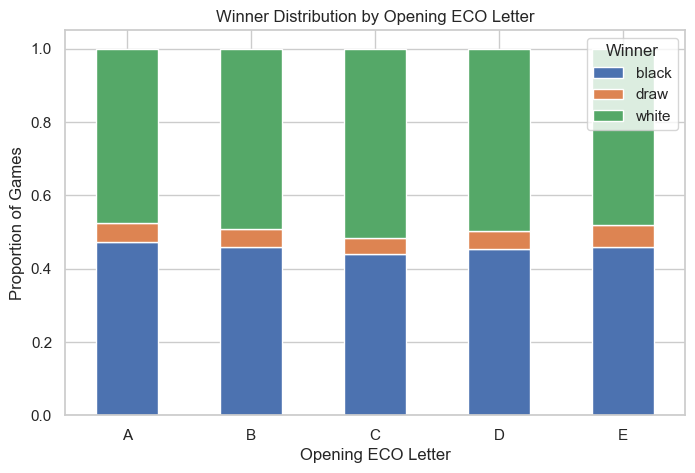

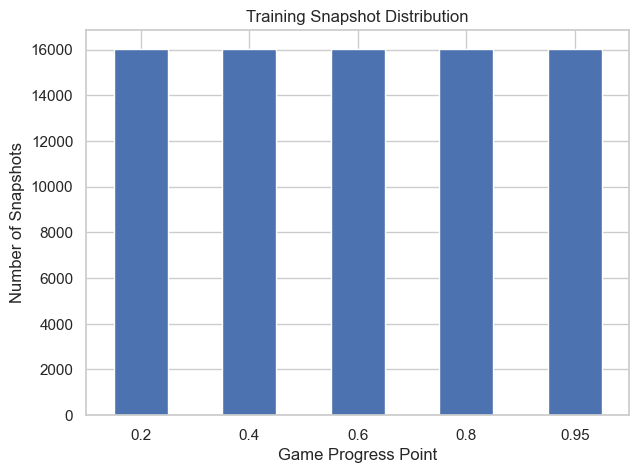

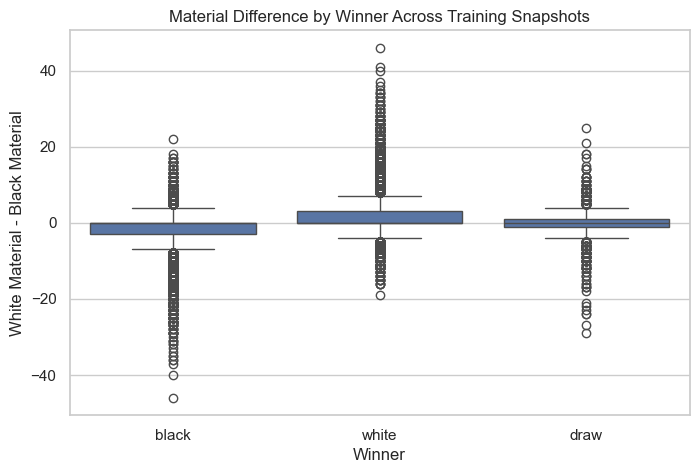

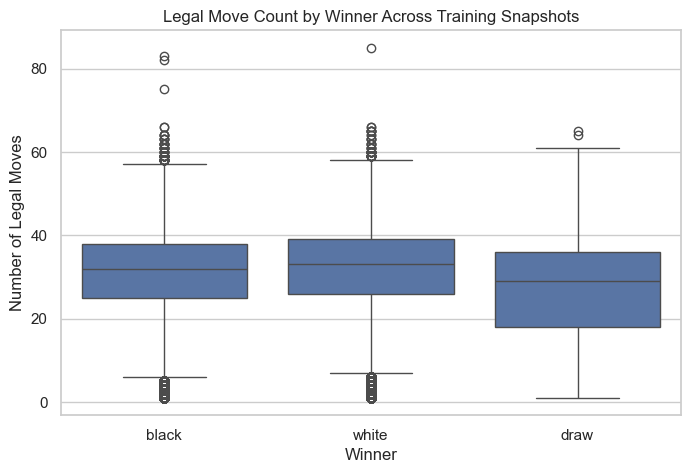

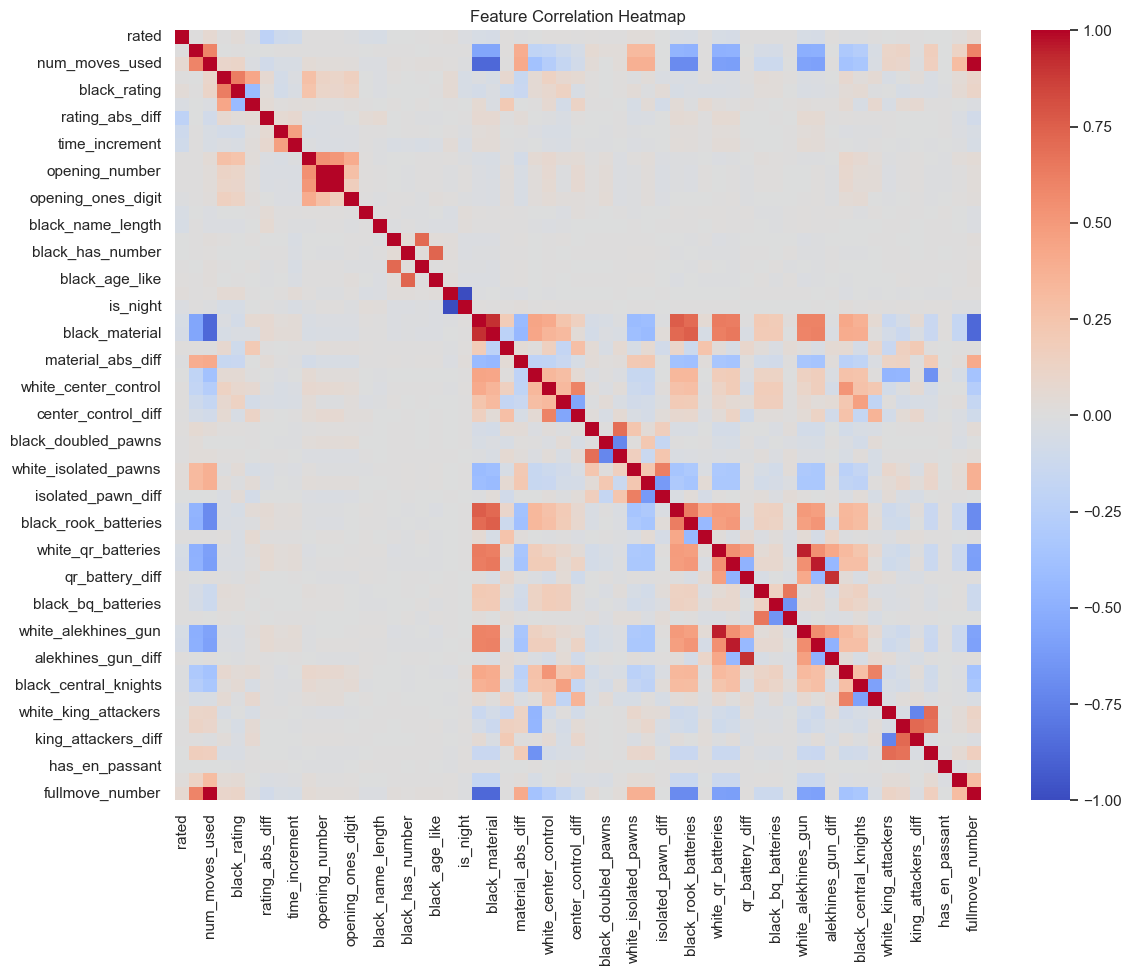

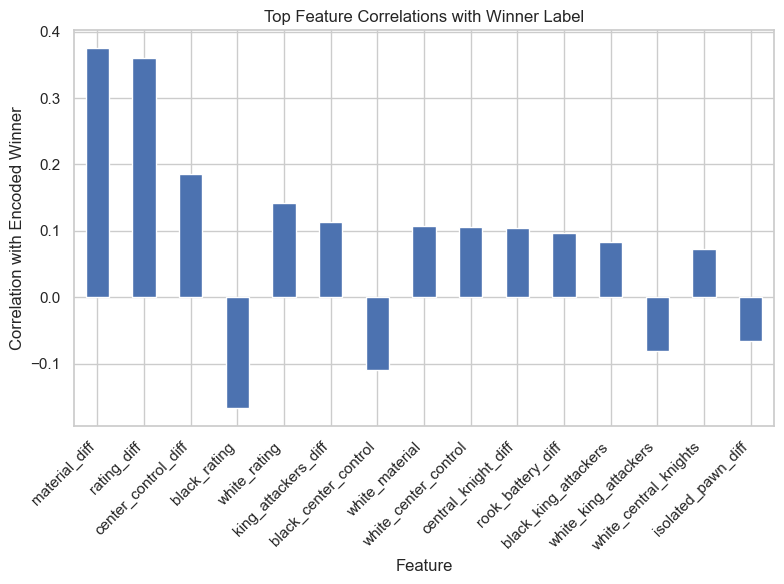

In [3]:
sns.set_theme(style="whitegrid")


# -------------------------------
# 1. Target Class Distributions
# -------------------------------

winner_class_counts = dataset["winner"].value_counts()
victory_status_counts = dataset["victory_status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

winner_class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution of Game Outcomes")
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("Number of Games")
axes[0].tick_params(axis="x", rotation=0)

victory_status_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Class Distribution of Victory Types")
axes[1].set_xlabel("Victory Type")
axes[1].set_ylabel("Number of Games")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# -------------------------------
# 2. Rating Distributions
# -------------------------------

plt.figure(figsize=(8, 5))
plt.hist(dataset["white_rating"], bins=40, alpha=0.6, label="White Rating")
plt.hist(dataset["black_rating"], bins=40, alpha=0.6, label="Black Rating")
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Games")
plt.legend()
plt.show()


# -------------------------------
# 3. Rating Difference vs Winner
# -------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(data=dataset, x="winner", y="rating_diff")
plt.title("Rating Difference by Game Outcome")
plt.xlabel("Winner")
plt.ylabel("White Rating - Black Rating")
plt.show()


# -------------------------------
# 4. Game Length Distribution
# -------------------------------

plt.figure(figsize=(8, 5))
plt.hist(dataset["turns"], bins=50)
plt.title("Distribution of Game Lengths")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Games")
plt.show()


# -------------------------------
# 5. Victory Type vs Game Length
# -------------------------------

plt.figure(figsize=(9, 5))
sns.boxplot(data=dataset, x="victory_status", y="turns")
plt.title("Game Length by Victory Type")
plt.xlabel("Victory Type")
plt.ylabel("Number of Turns")
plt.show()


# -------------------------------
# 6. Opening Strategy Distribution
# -------------------------------

opening_counts = dataset["opening_letter"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
opening_counts.plot(kind="bar")
plt.title("Opening ECO Letter Distribution")
plt.xlabel("ECO Opening Letter")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.show()


# -------------------------------
# 7. Opening Strategy vs Winner
# -------------------------------

opening_winner_table = pd.crosstab(
    dataset["opening_letter"],
    dataset["winner"],
    normalize="index"
)

opening_winner_table.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Winner Distribution by Opening ECO Letter")
plt.xlabel("Opening ECO Letter")
plt.ylabel("Proportion of Games")
plt.xticks(rotation=0)
plt.legend(title="Winner")
plt.show()


# -------------------------------
# 8. Snapshot Progress Distribution
# -------------------------------

plt.figure(figsize=(7, 5))
train_expanded["progress"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Snapshot Distribution")
plt.xlabel("Game Progress Point")
plt.ylabel("Number of Snapshots")
plt.xticks(rotation=0)
plt.show()


# -------------------------------
# 9. Material Difference by Winner
# -------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_expanded, x="winner", y="material_diff")
plt.title("Material Difference by Winner Across Training Snapshots")
plt.xlabel("Winner")
plt.ylabel("White Material - Black Material")
plt.show()


# -------------------------------
# 10. Mobility by Winner
# -------------------------------

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_expanded, x="winner", y="num_legal_moves")
plt.title("Legal Move Count by Winner Across Training Snapshots")
plt.xlabel("Winner")
plt.ylabel("Number of Legal Moves")
plt.show()


# -------------------------------
# 11. Correlation Heatmap
# -------------------------------

plot_feature_cols = [
    "rated",
    "progress",
    "num_moves_used",
    "white_rating",
    "black_rating",
    "rating_diff",
    "rating_abs_diff",
    "base_time",
    "time_increment",
    "opening_ply",
    "opening_number",
    "opening_tens_digit",
    "opening_ones_digit",
    "white_name_length",
    "black_name_length",
    "white_has_number",
    "black_has_number",
    "white_age_like",
    "black_age_like",
    "is_daytime",
    "is_night",
    "white_material",
    "black_material",
    "material_diff",
    "material_abs_diff",
    "num_legal_moves",
    "white_center_control",
    "black_center_control",
    "center_control_diff",
    "white_doubled_pawns",
    "black_doubled_pawns",
    "doubled_pawn_diff",
    "white_isolated_pawns",
    "black_isolated_pawns",
    "isolated_pawn_diff",
    "white_rook_batteries",
    "black_rook_batteries",
    "rook_battery_diff",
    "white_qr_batteries",
    "black_qr_batteries",
    "qr_battery_diff",
    "white_bq_batteries",
    "black_bq_batteries",
    "bq_battery_diff",
    "white_alekhines_gun",
    "black_alekhines_gun",
    "alekhines_gun_diff",
    "white_central_knights",
    "black_central_knights",
    "central_knight_diff",
    "white_king_attackers",
    "black_king_attackers",
    "king_attackers_diff",
    "side_to_move_in_check",
    "has_en_passant",
    "halfmove_clock",
    "fullmove_number",
]

plot_feature_cols = [col for col in plot_feature_cols if col in train_expanded.columns]

corr_matrix = train_expanded[plot_feature_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


# -------------------------------
# 12. Correlation with Encoded Winner
# -------------------------------

corr_with_winner = train_expanded[plot_feature_cols + ["y_winner"]].corr()["y_winner"]
corr_with_winner = corr_with_winner.drop("y_winner").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
corr_with_winner.head(15).plot(kind="bar")
plt.title("Top Feature Correlations with Winner Label")
plt.xlabel("Feature")
plt.ylabel("Correlation with Encoded Winner")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [4]:
x_train = X_train_global
x_test = X_test_global

y_train_winner = y_winner_train
y_test_winner = y_winner_test

y_train_status = y_status_train
y_test_status = y_status_test

y_train_multi = train_expanded[["winner", "victory_status"]]
y_test_multi = test_expanded[["winner", "victory_status"]]

groups = train_expanded["id"]

print("Random Forest training shape:", x_train.shape)
print("Random Forest testing shape:", x_test.shape)


param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

group_cv = GroupKFold(n_splits=5)
candidate_feature_counts = [10, 15, 20, 25, 30, 40, 50, 75, 99]


def get_feature_importance_ranking(x_train, y_train, feature_cols):
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(x_train, y_train)

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    return importance_df


def find_best_feature_set_single_output(
    x_train,
    y_train,
    feature_cols,
    groups,
    model_name,
    candidate_feature_counts
):
    print("\n" + "=" * 70)
    print(f"Finding best feature set for {model_name}")
    print("=" * 70)

    importance_df = get_feature_importance_ranking(
        x_train,
        y_train,
        feature_cols
    )

    results = []

    for k in candidate_feature_counts:
        k = min(k, len(feature_cols))
        selected_features = importance_df.head(k)["feature"].tolist()

        rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            rf,
            x_train[selected_features],
            y_train,
            cv=group_cv,
            groups=groups,
            scoring="f1_weighted",
            n_jobs=-1
        )

        results.append({
            "num_features": k,
            "mean_f1": scores.mean(),
            "std_f1": scores.std(),
            "features": selected_features
        })

        print(f"Top {k:3d} features | F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("mean_f1", ascending=False).iloc[0]

    best_features = best_row["features"]

    print("\nBest number of features:", best_row["num_features"])
    print("Best CV F1:", best_row["mean_f1"])

    return best_features, importance_df, results_df


def multioutput_f1_score(y_true, y_pred):
    y_true = np.asarray(y_true)

    winner_f1 = f1_score(
        y_true[:, 0],
        y_pred[:, 0],
        average="weighted",
        zero_division=0
    )

    status_f1 = f1_score(
        y_true[:, 1],
        y_pred[:, 1],
        average="weighted",
        zero_division=0
    )

    return (winner_f1 + status_f1) / 2


multioutput_scorer = make_scorer(multioutput_f1_score)


def find_best_feature_set_multi_output(
    x_train,
    y_train_multi,
    feature_cols,
    groups,
    model_name,
    candidate_feature_counts
):
    print("\n" + "=" * 70)
    print(f"Finding best feature set for {model_name}")
    print("=" * 70)

    # Rank features using winner + status importances averaged
    winner_importance = get_feature_importance_ranking(
        x_train,
        y_train_multi["winner"],
        feature_cols
    )

    status_importance = get_feature_importance_ranking(
        x_train,
        y_train_multi["victory_status"],
        feature_cols
    )

    merged_importance = winner_importance.merge(
        status_importance,
        on="feature",
        suffixes=("_winner", "_status")
    )

    merged_importance["importance"] = (
        merged_importance["importance_winner"] +
        merged_importance["importance_status"]
    ) / 2

    importance_df = merged_importance.sort_values("importance", ascending=False)

    results = []

    for k in candidate_feature_counts:
        k = min(k, len(feature_cols))
        selected_features = importance_df.head(k)["feature"].tolist()

        base_rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        multi_rf = MultiOutputClassifier(base_rf, n_jobs=-1)

        scores = cross_val_score(
            multi_rf,
            x_train[selected_features],
            y_train_multi,
            cv=group_cv,
            groups=groups,
            scoring=multioutput_scorer,
            n_jobs=-1
        )

        results.append({
            "num_features": k,
            "mean_f1": scores.mean(),
            "std_f1": scores.std(),
            "features": selected_features
        })

        print(f"Top {k:3d} features | Avg Multi-Output F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("mean_f1", ascending=False).iloc[0]

    best_features = best_row["features"]

    print("\nBest number of features:", best_row["num_features"])
    print("Best CV Avg F1:", best_row["mean_f1"])

    return best_features, importance_df, results_df


Random Forest training shape: (80230, 99)
Random Forest testing shape: (20060, 99)


In [5]:
winner_best_features, winner_importance_df, winner_feature_results = \
    find_best_feature_set_single_output(
        x_train=x_train,
        y_train=y_train_winner,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Winner RF",
        candidate_feature_counts=candidate_feature_counts
    )

status_best_features, status_importance_df, status_feature_results = \
    find_best_feature_set_single_output(
        x_train=x_train,
        y_train=y_train_status,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Victory Status RF",
        candidate_feature_counts=candidate_feature_counts
    )

multi_best_features, multi_importance_df, multi_feature_results = \
    find_best_feature_set_multi_output(
        x_train=x_train,
        y_train_multi=y_train_multi,
        feature_cols=feature_cols,
        groups=groups,
        model_name="Multi-Output RF",
        candidate_feature_counts=candidate_feature_counts
    )


Finding best feature set for Winner RF
Top  10 features | F1 = 0.6642 ± 0.0075
Top  15 features | F1 = 0.6681 ± 0.0072
Top  20 features | F1 = 0.6699 ± 0.0062
Top  25 features | F1 = 0.6716 ± 0.0052
Top  30 features | F1 = 0.6726 ± 0.0067
Top  40 features | F1 = 0.6738 ± 0.0058
Top  50 features | F1 = 0.6734 ± 0.0074
Top  75 features | F1 = 0.6757 ± 0.0075
Top  99 features | F1 = 0.6777 ± 0.0077

Best number of features: 99
Best CV F1: 0.6777108569789064

Finding best feature set for Victory Status RF
Top  10 features | F1 = 0.4986 ± 0.0089
Top  15 features | F1 = 0.5149 ± 0.0072
Top  20 features | F1 = 0.5162 ± 0.0077
Top  25 features | F1 = 0.5154 ± 0.0079
Top  30 features | F1 = 0.5143 ± 0.0086
Top  40 features | F1 = 0.5108 ± 0.0074
Top  50 features | F1 = 0.5092 ± 0.0079
Top  75 features | F1 = 0.5071 ± 0.0088
Top  99 features | F1 = 0.5049 ± 0.0061

Best number of features: 20
Best CV F1: 0.5162122054560196

Finding best feature set for Multi-Output RF
Top  10 features | Avg Mul

In [6]:
rf_winner_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_status_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

multi_rf_base = MultiOutputClassifier(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    n_jobs=-1
)

winner_search = RandomizedSearchCV(
    estimator=rf_winner_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

status_search = RandomizedSearchCV(
    estimator=rf_status_base,
    param_distributions=param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

multi_param_distributions = {
    "estimator__n_estimators": [100, 200, 300, 400],
    "estimator__max_depth": [None, 10, 20, 30, 40],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2", None]
}

multi_search = RandomizedSearchCV(
    estimator=multi_rf_base,
    param_distributions=multi_param_distributions,
    n_iter=15,
    cv=group_cv,
    scoring=multioutput_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Optimizing winner model...")
winner_search.fit(x_train[winner_best_features], y_train_winner, groups=groups)

print("\nOptimizing victory status model...")
status_search.fit(x_train[status_best_features], y_train_status, groups=groups)

print("\nOptimizing multi-output model...")
multi_search.fit(x_train[multi_best_features], y_train_multi, groups=groups)

rf_winner_best = winner_search.best_estimator_
rf_status_best = status_search.best_estimator_
rf_multi_best = multi_search.best_estimator_

print("\nBest winner parameters:")
print(winner_search.best_params_)
print("Best winner CV weighted F1:", winner_search.best_score_)

print("\nBest status parameters:")
print(status_search.best_params_)
print("Best status CV weighted F1:", status_search.best_score_)

print("\nBest multi-output parameters:")
print(multi_search.best_params_)
print("Best multi-output CV average F1:", multi_search.best_score_)

Optimizing winner model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimizing victory status model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimizing multi-output model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best winner parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Best winner CV weighted F1: 0.6828954968736776

Best status parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30}
Best status CV weighted F1: 0.5435080456708757

Best multi-output parameters:
{'estimator__n_estimators': 400, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 2, 'estimator__max_features': 'log2', 'estimator__max_depth': 30}
Best multi-output CV average F1: 0.6109170308447899


In [7]:
def evaluate_predictions(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision weighted:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall weighted:", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1 weighted:", f1_score(y_true, y_pred, average="weighted", zero_division=0))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [8]:
winner_pred = rf_winner_best.predict(x_test[winner_best_features])
status_pred = rf_status_best.predict(x_test[status_best_features])

multi_pred = rf_multi_best.predict(x_test[multi_best_features])
multi_winner_pred = multi_pred[:, 0]
multi_status_pred = multi_pred[:, 1]

evaluate_predictions(
    y_test_winner,
    winner_pred,
    "Selected Feature Winner RF"
)

evaluate_predictions(
    y_test_status,
    status_pred,
    "Selected Feature Status RF"
)

evaluate_predictions(
    y_test_winner,
    multi_winner_pred,
    "Selected Feature Multi-Output RF - Winner"
)

evaluate_predictions(
    y_test_status,
    multi_status_pred,
    "Selected Feature Multi-Output RF - Status"
)

def validate_all_rf_at_progress(progress_value):
    print("\n" + "=" * 70)
    print(f"Random Forest Validation at {int(progress_value * 100)}% Game Progress")
    print("=" * 70)

    progress_mask = np.isclose(test_expanded["progress"], progress_value)

    if progress_mask.sum() == 0:
        print(f"No test samples found for progress = {progress_value}")
        return

    y_winner_progress = test_expanded.loc[progress_mask, "winner"]
    y_status_progress = test_expanded.loc[progress_mask, "victory_status"]

    x_winner_progress = test_expanded.loc[progress_mask, winner_best_features].astype(float)
    x_status_progress = test_expanded.loc[progress_mask, status_best_features].astype(float)
    x_multi_progress = test_expanded.loc[progress_mask, multi_best_features].astype(float)

    winner_pred_progress = rf_winner_best.predict(x_winner_progress)
    status_pred_progress = rf_status_best.predict(x_status_progress)

    multi_pred_progress = rf_multi_best.predict(x_multi_progress)
    multi_winner_pred_progress = multi_pred_progress[:, 0]
    multi_status_pred_progress = multi_pred_progress[:, 1]

    evaluate_predictions(
        y_winner_progress,
        winner_pred_progress,
        f"Winner RF at {int(progress_value * 100)}%"
    )

    evaluate_predictions(
        y_status_progress,
        status_pred_progress,
        f"Status RF at {int(progress_value * 100)}%"
    )

    evaluate_predictions(
        y_winner_progress,
        multi_winner_pred_progress,
        f"Multi-Output RF Winner at {int(progress_value * 100)}%"
    )

    evaluate_predictions(
        y_status_progress,
        multi_status_pred_progress,
        f"Multi-Output RF Status at {int(progress_value * 100)}%"
    )

progress_points_to_test = [0.2, 0.4, 0.6, 0.8, 0.95]

for p in progress_points_to_test:
    validate_all_rf_at_progress(p)


--- Selected Feature Winner RF ---
Accuracy: 0.7167497507477567
Precision weighted: 0.7117050113733239
Recall weighted: 0.7167497507477567
F1 weighted: 0.7102570799587992

Classification Report:
              precision    recall  f1-score   support

       black       0.71      0.72      0.72      9110
        draw       0.55      0.20      0.30       950
       white       0.73      0.76      0.74     10000

    accuracy                           0.72     20060
   macro avg       0.66      0.56      0.59     20060
weighted avg       0.71      0.72      0.71     20060


--- Selected Feature Status RF ---
Accuracy: 0.6029411764705882
Precision weighted: 0.5840407205576161
Recall weighted: 0.6029411764705882
F1 weighted: 0.5799117567606364

Classification Report:
              precision    recall  f1-score   support

        draw       0.43      0.20      0.28       900
        mate       0.55      0.44      0.49      6475
   outoftime       0.46      0.20      0.28      1760
      resi

In [9]:
# ------------------------------------------------------------
# 1. SAN Subtokenization
# ------------------------------------------------------------

def san_to_subtokens(san):
    san = str(san).strip()
    san = san.replace("!", "").replace("?", "")

    if san == "O-O":
        return ["castle_kingside"]
    if san == "O-O-O":
        return ["castle_queenside"]

    tokens = []

    suffix_tokens = []
    while len(san) > 0 and san[-1] in ["+", "#"]:
        if san[-1] == "+":
            suffix_tokens.append("check")
        elif san[-1] == "#":
            suffix_tokens.append("mate")
        san = san[:-1]

    promo_match = re.search(r"=([QRBN])", san)
    if promo_match:
        promo_piece = promo_match.group(1)
        san = re.sub(r"=([QRBN])", "", san)
        promo_token = f"promo_{promo_piece}"
    else:
        promo_token = None

    dest_match = re.search(r"([a-h][1-8])$", san)

    if not dest_match:
        return [f"raw_{san}"] + suffix_tokens

    dest = dest_match.group(1)
    san_core = san[:-2]

    if len(san_core) > 0 and san_core[0] in "KQRBN":
        piece = san_core[0]
        san_core = san_core[1:]
    else:
        piece = "P"

    tokens.append(piece)

    if "x" in san_core:
        before_capture, after_capture = san_core.split("x", 1)

        if before_capture:
            for ch in before_capture:
                tokens.append(f"src_{ch}")

        tokens.append("x")

        if after_capture:
            for ch in after_capture:
                tokens.append(f"hint_{ch}")

    else:
        if san_core:
            for ch in san_core:
                tokens.append(f"src_{ch}")

    tokens.append(f"dst_{dest}")

    if promo_token is not None:
        tokens.append(promo_token)

    tokens.extend(reversed(suffix_tokens))

    return tokens


def move_string_to_subtokens(move_string):
    moves = str(move_string).split()
    all_tokens = []

    for move in moves:
        all_tokens.append("<m>")
        all_tokens.extend(san_to_subtokens(move))

    return " ".join(all_tokens)


# ------------------------------------------------------------
# 2. Build Subtokenized Move Strings
# ------------------------------------------------------------

train_expanded["moves_subtok"] = train_expanded["moves_truncated"].apply(move_string_to_subtokens)
test_expanded["moves_subtok"] = test_expanded["moves_truncated"].apply(move_string_to_subtokens)

train_move_text = train_expanded["moves_subtok"].astype(str).values
test_move_text = test_expanded["moves_subtok"].astype(str).values


# ------------------------------------------------------------
# 3. Text Vectorization
# ------------------------------------------------------------

train_subtok_lengths = train_expanded["moves_subtok"].apply(lambda x: len(str(x).split()))

sequence_length = int(np.percentile(train_subtok_lengths, 95))
sequence_length = max(sequence_length, 20)

vectorizer = TextVectorization(
    max_tokens=30000,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=None,
    split="whitespace"
)

vectorizer.adapt(train_move_text)

vocab_size = len(vectorizer.get_vocabulary())

X_moves_train = vectorizer(train_move_text).numpy()
X_moves_test = vectorizer(test_move_text).numpy()


# ------------------------------------------------------------
# 4. Extra Numeric Features
# ------------------------------------------------------------

extra_scaler = StandardScaler()

X_extra_train = extra_scaler.fit_transform(X_train_global).astype(np.float32)
X_extra_test = extra_scaler.transform(X_test_global).astype(np.float32)


# ------------------------------------------------------------
# 5. Labels
# ------------------------------------------------------------

y_winner_train_tf = train_expanded["y_winner"].values
y_winner_test_tf = test_expanded["y_winner"].values

y_status_train_tf = train_expanded["y_status"].values
y_status_test_tf = test_expanded["y_status"].values

n_winner_classes = len(winner_encoder.classes_)
n_status_classes = len(status_encoder.classes_)


print("Sequence length:", sequence_length)
print("Vocabulary size:", vocab_size)
print("X_moves_train shape:", X_moves_train.shape)
print("X_extra_train shape:", X_extra_train.shape)
print("Winner classes:", list(winner_encoder.classes_))
print("Status classes:", list(status_encoder.classes_))

Sequence length: 304
Vocabulary size: 99
X_moves_train shape: (80230, 304)
X_extra_train shape: (80230, 99)
Winner classes: ['black', 'draw', 'white']
Status classes: ['draw', 'mate', 'outoftime', 'resign']


In [10]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True
        )
        self.pos_emb = Embedding(
            input_dim=maxlen,
            output_dim=embed_dim
        )

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)

        token_embeddings = self.token_emb(x)

        return token_embeddings + positions

    def compute_mask(self, inputs, mask=None):
        return self.token_emb.compute_mask(inputs)


class MaskedGlobalAveragePooling1D(layers.Layer):
    def call(self, inputs, mask=None):
        if mask is None:
            return tf.reduce_mean(inputs, axis=1)

        mask = tf.cast(mask, inputs.dtype)
        mask = tf.expand_dims(mask, axis=-1)

        masked_inputs = inputs * mask
        sum_inputs = tf.reduce_sum(masked_inputs, axis=1)
        denom = tf.reduce_sum(mask, axis=1)

        return sum_inputs / tf.maximum(denom, tf.ones_like(denom))

    def compute_mask(self, inputs, mask=None):
        return None


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)

        self.drop1 = Dropout(rate)
        self.drop2 = Dropout(rate)

    def call(self, x, training=False, mask=None):
        attention_mask = None

        if mask is not None:
            attention_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)

        attn_output = self.att(
            x,
            x,
            attention_mask=attention_mask,
            training=training
        )

        attn_output = self.drop1(attn_output, training=training)
        out1 = self.ln1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.drop2(ffn_output, training=training)

        return self.ln2(out1 + ffn_output)

    def compute_mask(self, inputs, mask=None):
        return mask


def build_hybrid_transformer(
    vocab_size,
    maxlen,
    extra_dim,
    n_winner_classes,
    n_status_classes,
    embed_dim=64,
    num_heads=4,
    ff_dim=128
):

    moves_input = Input(shape=(maxlen,), name="moves_input")

    x_seq = TokenAndPositionEmbedding(
        maxlen=maxlen,
        vocab_size=vocab_size,
        embed_dim=embed_dim
    )(moves_input)

    x_seq = TransformerBlock(embed_dim, num_heads, ff_dim)(x_seq)
    x_seq = TransformerBlock(embed_dim, num_heads, ff_dim)(x_seq)
    x_seq = MaskedGlobalAveragePooling1D()(x_seq)
    x_seq = Dropout(0.1)(x_seq)

    extra_input = Input(shape=(extra_dim,), name="extra_input")

    x_extra = Dense(128, activation="relu")(extra_input)
    x_extra = Dropout(0.1)(x_extra)
    x_extra = Dense(64, activation="relu")(x_extra)
    x_extra = Dropout(0.1)(x_extra)

    x = Concatenate()([x_seq, x_extra])

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.1)(x)

    winner_branch = Dense(64, activation="relu")(x)
    winner_branch = Dropout(0.1)(winner_branch)
    winner_output = Dense(
        n_winner_classes,
        activation="softmax",
        name="winner_output"
    )(winner_branch)

    status_branch = Dense(64, activation="relu")(x)
    status_branch = Dropout(0.1)(status_branch)
    status_output = Dense(
        n_status_classes,
        activation="softmax",
        name="status_output"
    )(status_branch)

    model = Model(
        inputs=[moves_input, extra_input],
        outputs=[winner_output, status_output]
    )

    model.compile(
        optimizer="adam",
        loss=[
            "sparse_categorical_crossentropy",
            "sparse_categorical_crossentropy"
        ],
        loss_weights=[1.0, 1.3],
        metrics=[
            ["accuracy"],
            ["accuracy"]
        ]
    )

    return model


hybrid_model = build_hybrid_transformer(
    vocab_size=vocab_size,
    maxlen=sequence_length,
    extra_dim=X_extra_train.shape[1],
    n_winner_classes=n_winner_classes,
    n_status_classes=n_status_classes
)

hybrid_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ moves_input         │ (None, 304)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 304, 64)   │     25,792 │ moves_input[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 304)       │          0 │ moves_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_input         │ (None, 99)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 304, 64)   │     83,200 │ token_and_positi… │
│ (TransformerBlock)  │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     12,800 │ extra_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 304, 64)   │     83,200 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_global_aver… │ (None, 64)        │          0 │ transformer_bloc… │
│ (MaskedGlobalAvera… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ masked_global_av… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      4,160 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      4,160 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                 

 Total params: 246,791 (964.03 KB)

 Trainable params: 246,791 (964.03 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
winner_weights_auto = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_winner_train_tf),
    y=y_winner_train_tf
)

status_weights_auto = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_status_train_tf),
    y=y_status_train_tf
)

winner_class_weights = {
    i: float(np.sqrt(w)) for i, w in enumerate(winner_weights_auto)
}

status_class_weights = {
    i: float(np.sqrt(w)) for i, w in enumerate(status_weights_auto)
}

winner_sample_weights = np.array(
    [winner_class_weights[label] for label in y_winner_train_tf],
    dtype=np.float32
)

status_sample_weights = np.array(
    [status_class_weights[label] for label in y_status_train_tf],
    dtype=np.float32
)

print("Winner class weights:", winner_class_weights)
print("Status class weights:", status_class_weights)


# Explicit validation split instead of validation_split=0.1
(
    X_moves_train_fit,
    X_moves_val,
    X_extra_train_fit,
    X_extra_val,
    y_winner_train_fit,
    y_winner_val,
    y_status_train_fit,
    y_status_val,
    winner_weights_train_fit,
    winner_weights_val,
    status_weights_train_fit,
    status_weights_val
) = train_test_split(
    X_moves_train,
    X_extra_train,
    y_winner_train_tf,
    y_status_train_tf,
    winner_sample_weights,
    status_sample_weights,
    test_size=0.1,
    random_state=42,
    stratify=y_winner_train_tf
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5
)


history = hybrid_model.fit(
    [X_moves_train_fit, X_extra_train_fit],
    [y_winner_train_fit, y_status_train_fit],
    sample_weight=[winner_weights_train_fit, status_weights_train_fit],
    validation_data=(
        [X_moves_val, X_extra_val],
        [y_winner_val, y_status_val]
    ),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Winner class weights: {0: 0.8568562887737202, 1: 2.652870011562122, 2: 0.8176183528162608}
Status class weights: {0: 2.350634402382453, 1: 0.8930369032334439, 2: 1.73801836334525, 3: 0.669038220244022}
Epoch 1/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 378s 329ms/step - loss: 2.2494 - status_output_accuracy: 0.5535 - status_output_loss: 1.1163 - winner_output_accuracy: 0.6613 - winner_output_loss: 0.7983 - val_loss: 2.1263 - val_status_output_accuracy: 0.5660 - val_status_output_loss: 1.0651 - val_winner_output_accuracy: 0.6761 - val_winner_output_loss: 0.7411 - learning_rate: 0.0010
Epoch 2/20
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 369s 326ms/step - loss: 2.1636 - status_output_accuracy: 0.5669 - status_output_loss: 1.0814 - winner_output_accuracy: 0.6795 - winner_output_loss: 0.7581 - val_loss: 2.1474 - val_status_output_accuracy: 0.5689 - val_status_output_loss: 1.0749 - val_winner_output_accuracy: 0.6728 - val_winner_output_loss: 0.7497 - learning_rate: 0.0010
Epoch 3/20
1129/1129 ━━━━━━━━━━━━━━━━━


HYBRID TRANSFORMER TEST RESULTS AT 20% OF GAME

--- Winner Model at 20% ---
Accuracy : 0.6129
Precision: 0.6085
Recall   : 0.6129
F1       : 0.6106

Classification Report:
              precision    recall  f1-score   support

       black       0.62      0.62      0.62      1822
        draw       0.17      0.14      0.15       190
       white       0.64      0.65      0.65      2000

    accuracy                           0.61      4012
   macro avg       0.48      0.47      0.47      4012
weighted avg       0.61      0.61      0.61      4012


--- Victory Status Model at 20% ---
Accuracy : 0.5351
Precision: 0.4913
Recall   : 0.5351
F1       : 0.4478

Classification Report:
              precision    recall  f1-score   support

        draw       0.17      0.14      0.16       180
        mate       0.48      0.12      0.19      1295
   outoftime       0.29      0.03      0.05       352
      resign       0.56      0.90      0.69      2185

    accuracy                           0.

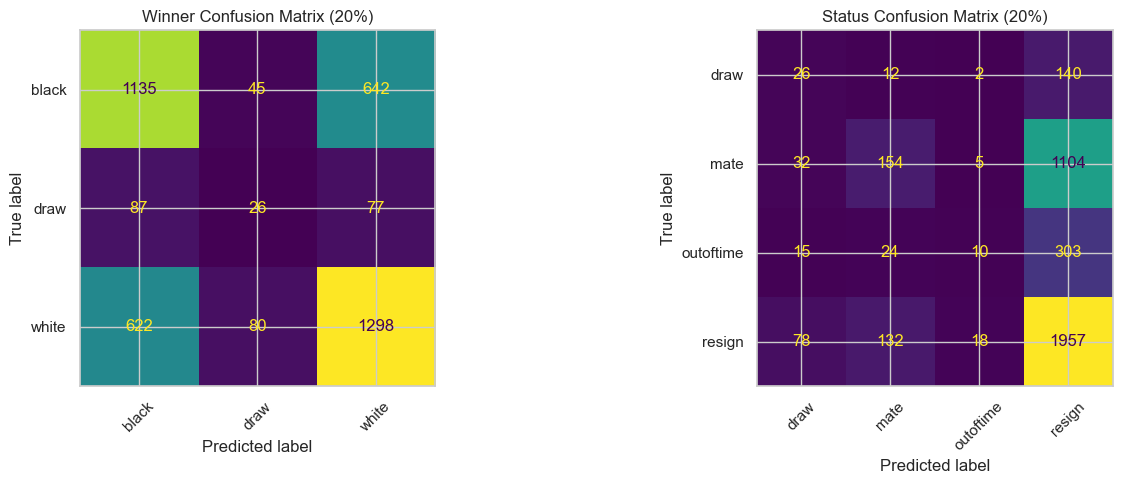


HYBRID TRANSFORMER TEST RESULTS AT 40% OF GAME

--- Winner Model at 40% ---
Accuracy : 0.6254
Precision: 0.6247
Recall   : 0.6254
F1       : 0.6245

Classification Report:
              precision    recall  f1-score   support

       black       0.62      0.66      0.64      1822
        draw       0.19      0.17      0.18       190
       white       0.67      0.64      0.65      2000

    accuracy                           0.63      4012
   macro avg       0.49      0.49      0.49      4012
weighted avg       0.62      0.63      0.62      4012


--- Victory Status Model at 40% ---
Accuracy : 0.5339
Precision: 0.4873
Recall   : 0.5339
F1       : 0.4783

Classification Report:
              precision    recall  f1-score   support

        draw       0.18      0.18      0.18       180
        mate       0.45      0.21      0.29      1295
   outoftime       0.22      0.04      0.07       352
      resign       0.58      0.83      0.68      2185

    accuracy                           0.

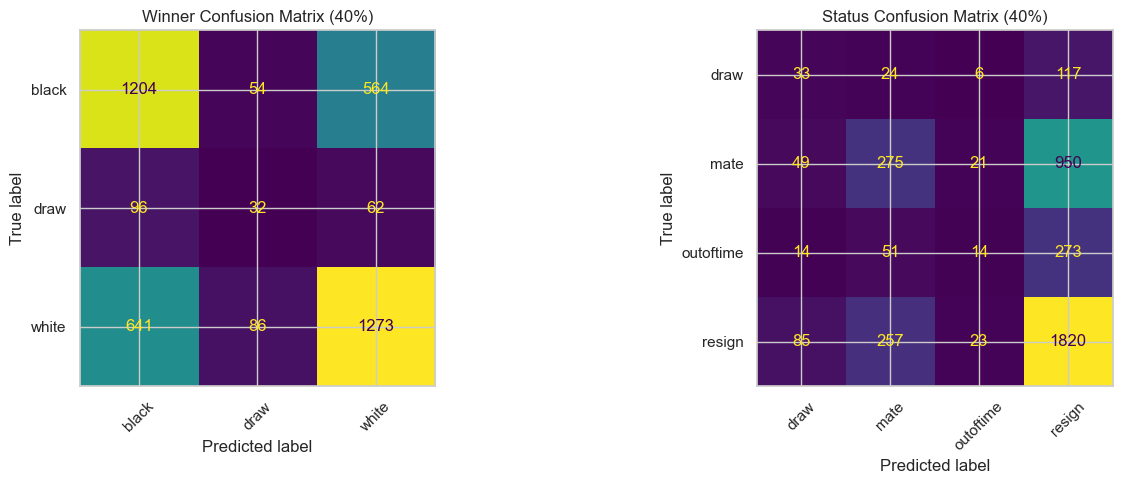


HYBRID TRANSFORMER TEST RESULTS AT 60% OF GAME

--- Winner Model at 60% ---
Accuracy : 0.6695
Precision: 0.6722
Recall   : 0.6695
F1       : 0.6704

Classification Report:
              precision    recall  f1-score   support

       black       0.67      0.71      0.69      1822
        draw       0.18      0.19      0.19       190
       white       0.72      0.68      0.70      2000

    accuracy                           0.67      4012
   macro avg       0.52      0.53      0.53      4012
weighted avg       0.67      0.67      0.67      4012


--- Victory Status Model at 60% ---
Accuracy : 0.5384
Precision: 0.5132
Recall   : 0.5384
F1       : 0.5115

Classification Report:
              precision    recall  f1-score   support

        draw       0.17      0.19      0.18       180
        mate       0.49      0.31      0.38      1295
   outoftime       0.25      0.12      0.16       352
      resign       0.60      0.77      0.67      2185

    accuracy                           0.

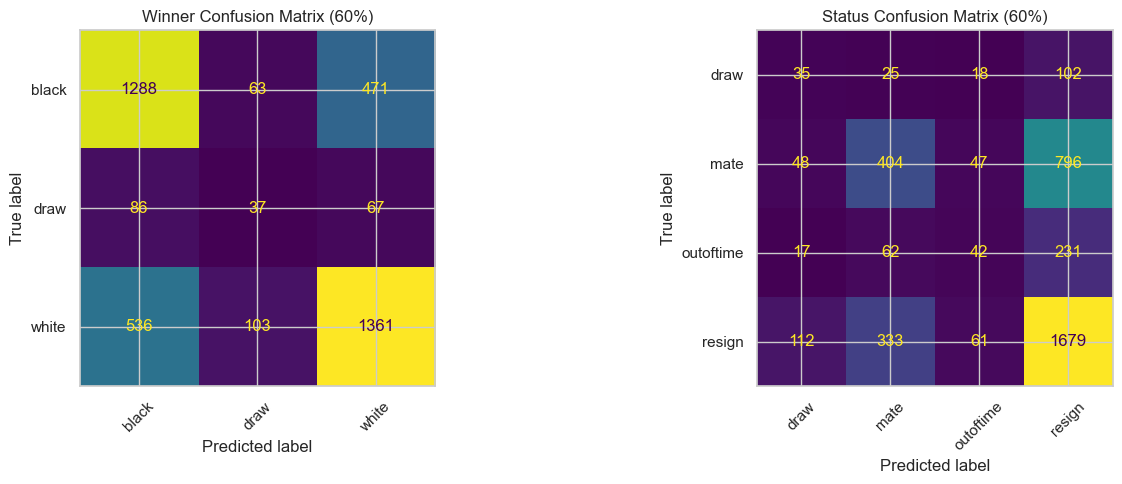


HYBRID TRANSFORMER TEST RESULTS AT 80% OF GAME

--- Winner Model at 80% ---
Accuracy : 0.6992
Precision: 0.7038
Recall   : 0.6992
F1       : 0.7009

Classification Report:
              precision    recall  f1-score   support

       black       0.70      0.74      0.72      1822
        draw       0.20      0.22      0.21       190
       white       0.75      0.71      0.73      2000

    accuracy                           0.70      4012
   macro avg       0.55      0.56      0.55      4012
weighted avg       0.70      0.70      0.70      4012


--- Victory Status Model at 80% ---
Accuracy : 0.5456
Precision: 0.5373
Recall   : 0.5456
F1       : 0.5398

Classification Report:
              precision    recall  f1-score   support

        draw       0.17      0.20      0.18       180
        mate       0.51      0.45      0.48      1295
   outoftime       0.21      0.17      0.19       352
      resign       0.63      0.69      0.66      2185

    accuracy                           0.

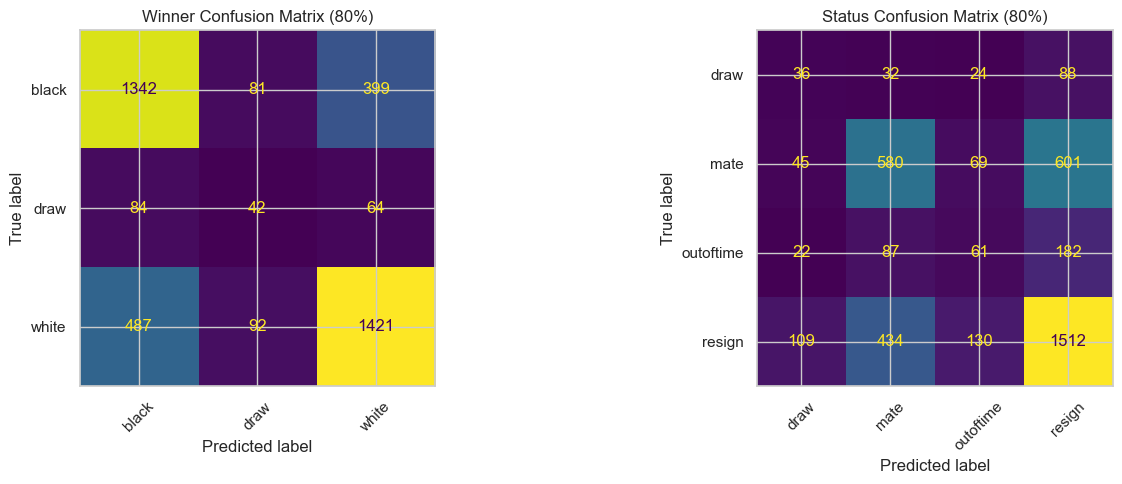


HYBRID TRANSFORMER TEST RESULTS AT 95% OF GAME

--- Winner Model at 95% ---
Accuracy : 0.7505
Precision: 0.7553
Recall   : 0.7505
F1       : 0.7527

Classification Report:
              precision    recall  f1-score   support

       black       0.76      0.78      0.77      1822
        draw       0.21      0.24      0.22       190
       white       0.80      0.77      0.79      2000

    accuracy                           0.75      4012
   macro avg       0.59      0.60      0.59      4012
weighted avg       0.76      0.75      0.75      4012


--- Victory Status Model at 95% ---
Accuracy : 0.5486
Precision: 0.5622
Recall   : 0.5486
F1       : 0.5534

Classification Report:
              precision    recall  f1-score   support

        draw       0.20      0.23      0.21       180
        mate       0.51      0.58      0.54      1295
   outoftime       0.23      0.24      0.23       352
      resign       0.68      0.61      0.64      2185

    accuracy                           0.

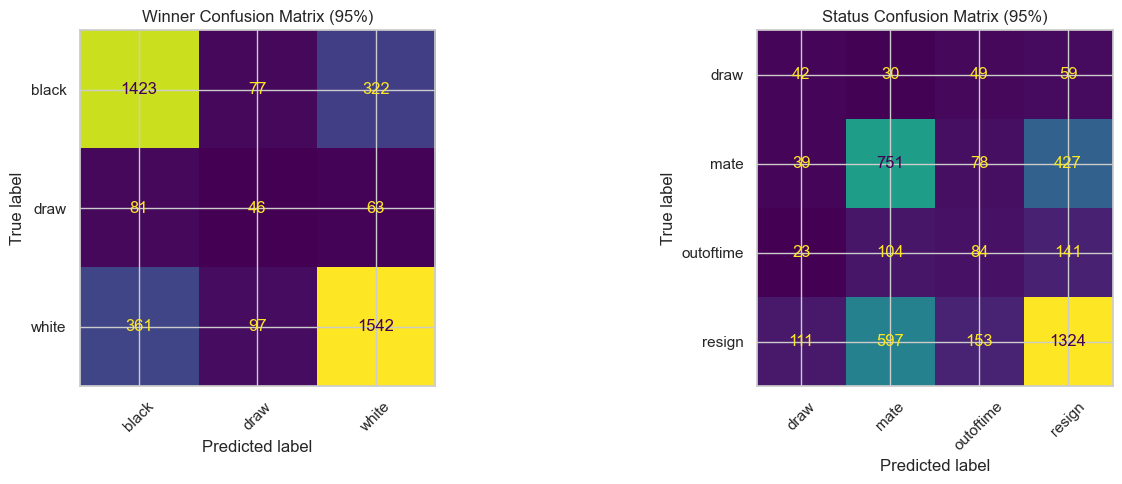

In [12]:
def build_transformer_phase_data(progress_value):
    phase_df = test_expanded[test_expanded["progress"] == progress_value].copy()

    phase_df["moves_subtok"] = phase_df["moves_truncated"].apply(move_string_to_subtokens)

    phase_move_text = phase_df["moves_subtok"].astype(str).values
    X_moves_phase = vectorizer(phase_move_text).numpy()

    X_extra_phase = extra_scaler.transform(
        phase_df[feature_cols].astype(float)
    ).astype(np.float32)

    y_winner_phase = phase_df["y_winner"].values
    y_status_phase = phase_df["y_status"].values

    return phase_df, X_moves_phase, X_extra_phase, y_winner_phase, y_status_phase


def print_transformer_metrics(y_true, y_pred, model_name, class_names):
    print(f"\n--- {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )


def evaluate_transformer_at_progress(progress_value):
    phase_df, X_moves_phase, X_extra_phase, y_winner_phase, y_status_phase = (
        build_transformer_phase_data(progress_value)
    )

    if len(phase_df) == 0:
        print(f"No test samples found at progress={progress_value}")
        return

    winner_pred_probs, status_pred_probs = hybrid_model.predict(
        {
            "moves_input": X_moves_phase,
            "extra_input": X_extra_phase
        },
        verbose=0
    )

    winner_pred = np.argmax(winner_pred_probs, axis=1)
    status_pred = np.argmax(status_pred_probs, axis=1)

    print("\n" + "=" * 70)
    print(f"HYBRID TRANSFORMER TEST RESULTS AT {int(progress_value * 100)}% OF GAME")
    print("=" * 70)

    print_transformer_metrics(
        y_winner_phase,
        winner_pred,
        f"Winner Model at {int(progress_value * 100)}%",
        winner_encoder.classes_
    )

    print_transformer_metrics(
        y_status_phase,
        status_pred,
        f"Victory Status Model at {int(progress_value * 100)}%",
        status_encoder.classes_
    )

    winner_cm = confusion_matrix(y_winner_phase, winner_pred)
    status_cm = confusion_matrix(y_status_phase, status_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    winner_disp = ConfusionMatrixDisplay(
        confusion_matrix=winner_cm,
        display_labels=winner_encoder.classes_
    )
    winner_disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"Winner Confusion Matrix ({int(progress_value * 100)}%)")
    axes[0].tick_params(axis="x", rotation=45)

    status_disp = ConfusionMatrixDisplay(
        confusion_matrix=status_cm,
        display_labels=status_encoder.classes_
    )
    status_disp.plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"Status Confusion Matrix ({int(progress_value * 100)}%)")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


progress_points_to_test = [0.2, 0.4, 0.6, 0.8, 0.95]

for progress in progress_points_to_test:
    evaluate_transformer_at_progress(progress)